In [1]:
import pandas as pd 
df_retail = pd.read_csv(r"C:\Users\Student\Downloads\OISIS ONLYBYTE\retail_sales_dataset.csv")
df_retail

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


# Initial inspection


In [2]:
#Shape 
df_retail.shape

(1000, 9)

### There are nine columns and 1000 rows

In [3]:
#Data types and null value check
df_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


### Checking the data inconsistances 

# Decriptive Statistics

In [4]:
df_retail.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


### The average transactin value is 25 with a standard deviation 559.99, indicating high variability in purchase amounts. The meadian Total amount is 135.00, suggesting the distribution is right-skewed with some very large purchase pulling the mean up.

# Time series Analysis

In [5]:
from matplotlib import pyplot as plt 
df_retail['Date'] = pd.to_datetime (df_retail['Date'], format = 'ISO8601')
df_retail['Month'] = df_retail['Date'].dt.to_period('M')
df_retail['Quarter'] = df_retail['Date'].dt.to_period('Q')

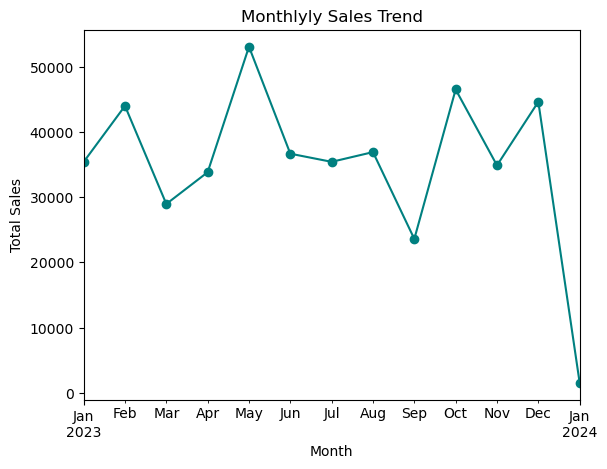

In [6]:
# Monthly Sales Trend 
monthly_sales = df_retail.groupby('Month')['Total Amount'].sum()
monthly_sales.plot(kind = 'line', marker ='o', color = 'teal')
plt.title('Monthlyly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

### The monthly sales trend show seasonality with peaks in certain months. The highest sales occured in May reaching approximately R50000, indicating strong seasonal demand during that period

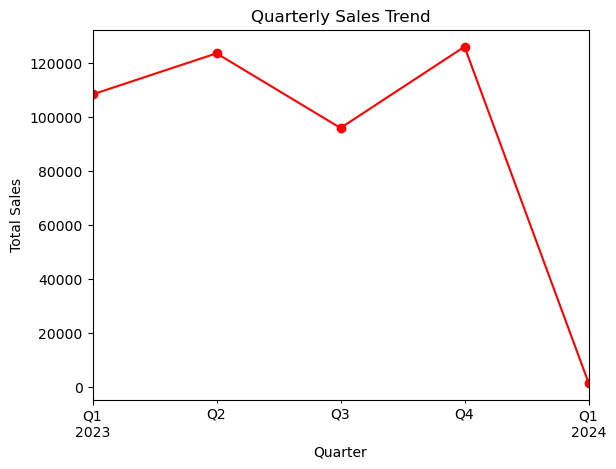

In [13]:
Quarterly_sales = df_retail.groupby('Quarter')['Total Amount'].sum()
Quarterly_sales.plot(kind = 'line', marker ='o', color = 'r')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.show()

## The monthly sales trend show seasonality with peaks in certain Quarters. The highest sales occured in Quater 4 reaching approximately R130000, indicating strong seasonal demand during that period

# Product Analysis

# Top 10 Products 

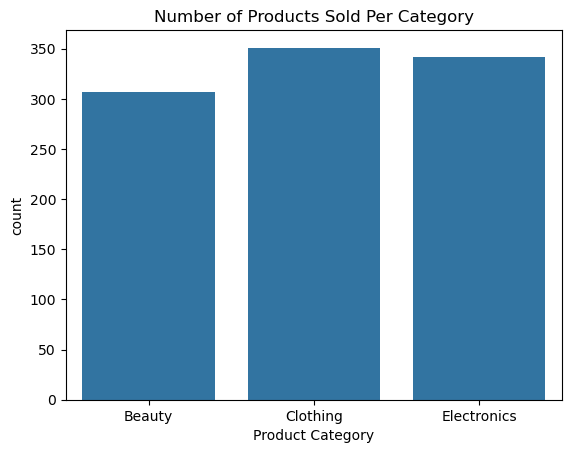

In [9]:
# Number of Products Sold Per Category
import seaborn as sns
sns.countplot(x = 'Product Category', data = df_retail)
plt.title('Number of Products Sold Per Category')
plt.show()

### The Clothing category has the highest number of products sold, followed by Electronics and Beauty. This suggestes the stores product mix is heavyily weighted toward apparel

# Customer Demographics Analysis 

In [10]:
# Creating age group
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ['0 - 18', '19 - 25', '26 - 35', '36 - 45', '46 - 60', '60+']
df_retail['Age Group'] = pd.cut(df_retail['Age'], bins = bins, labels = labels, right = False)


C:\Users\Student\AppData\Local\Temp\ipykernel_18868\2943813636.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df_retail.groupby('Age Group')['Total Amount'].sum().sort_index()


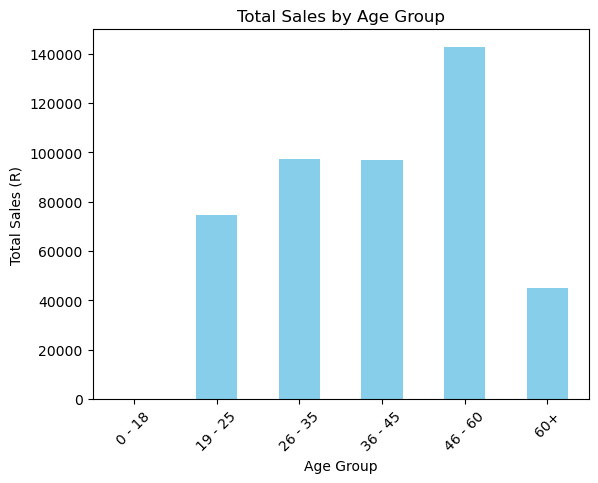

In [12]:
age_sales = df_retail.groupby('Age Group')['Total Amount'].sum().sort_index()
age_sales.plot(kind = 'bar', color = 'skyblue')
plt.title('Total Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales (R)')
plt.xticks(rotation = 45)
plt.show()

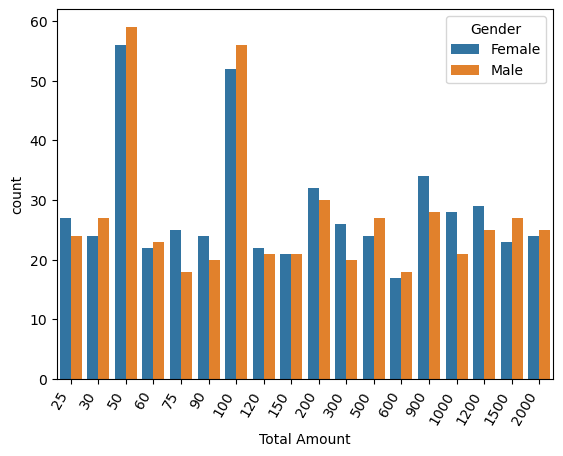

In [52]:
sns.countplot(data = df_retail, x = 'Total Amount', hue = 'Gender')
plt.xticks(rotation = 60, ha = 'right')
plt.show()

# Heatmap 

In [108]:
#Select only numeric cols
numeric_cols = df_retail.select_dtypes(include = ['float64','int64']).columns
corr = df_retail[numeric_cols].corr()

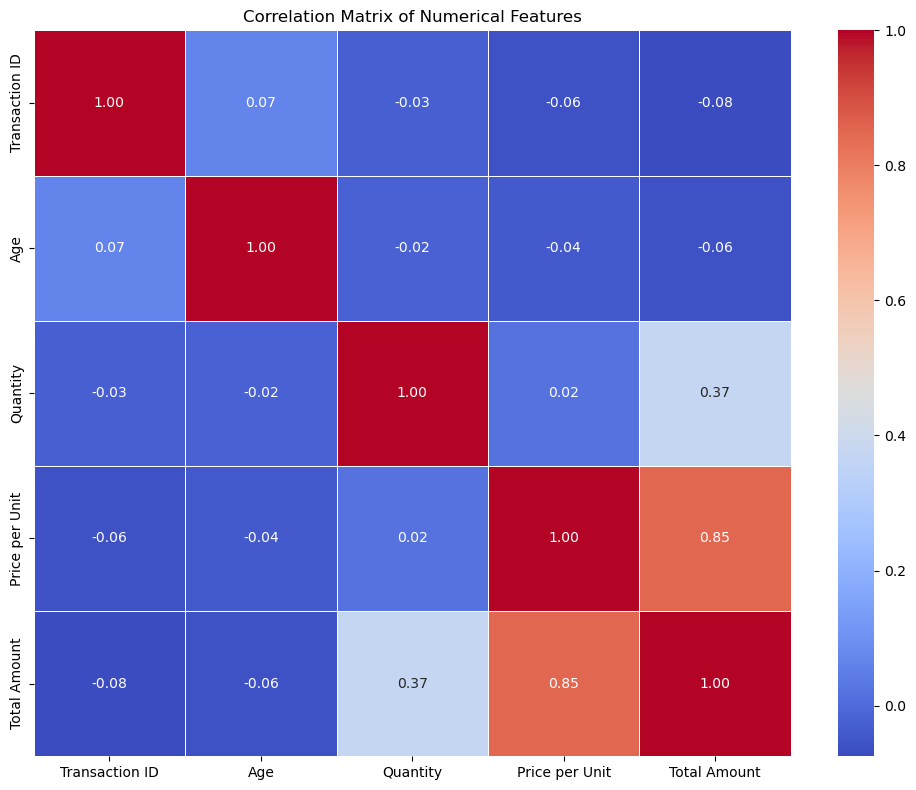

In [112]:
# Heatmap
plt.figure(figsize = (10,8))
sns.heatmap(corr,annot = True, cmap = 'coolwarm',fmt ='.2f',linewidths =0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

### The correlation matrix shows a strong positive correlation between Quantity and Total Amount(r = 0.85), indicating that higher purchases drive revenue. Price per Unit shows moderate correlation with Total Amount

# Gender per Quantity Sold (Additional Visual)

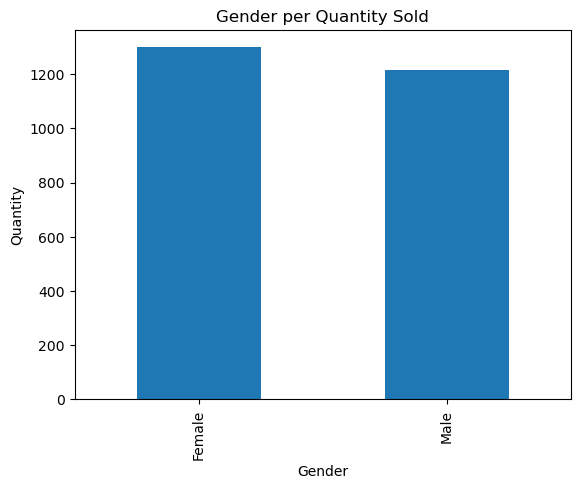

In [104]:
Gender_quantity = df_retail.groupby('Gender')['Quantity']. sum().plot.bar()
plt.title('Gender per Quantity Sold')
plt.xlabel('Gender')
plt.ylabel('Quantity')
plt.show()

### The above visual shows the qoantity solde per gender. Females had the highest quantity sold with approximately 1300 quantity sold and males with approximately 1200 quantity sold 